#NAME: SEBA SAUD

# M4.Ex1: Housing Prices Model (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

### Load the data

In [2]:
!pip install autogluon.tabular --quiet

import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
data = pd.read_csv('housing.csv')
display(data.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [4]:
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor


train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

predictor = TabularPredictor(label='median_house_value', problem_type='regression').fit(
    train_data,
    presets='medium_quality',
    time_limit=60
)


lb = predictor.leaderboard(test_data, silent=True)
display(lb[['model', 'score_test', 'score_val']].style.background_gradient(cmap='Blues'))

No path specified. Models will be saved in: "AutogluonModels/ag-20260422_120307"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.98 GB / 12.67 GB (86.7%)
Disk Space Avail:   86.26 GB / 107.72 GB (80.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "/content/AutogluonModels/ag-20260422_120307"
Train Data Rows:    16512
Train Data Columns: 9
Label Column:       median_house_value
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:       

[1000]	valid_set's rmse: 49409.6
[2000]	valid_set's rmse: 48518.2
[3000]	valid_set's rmse: 48360
[4000]	valid_set's rmse: 48312.8
[5000]	valid_set's rmse: 48307.8


	-48253.7613	 = Validation score   (-root_mean_squared_error)
	8.95s	 = Training   runtime
	0.96s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 49.40s of the 49.39s of remaining time.
	Fitting with cpus=1, gpus=0, mem=0.0/11.0 GB


[1000]	valid_set's rmse: 45813.7


	-45803.2746	 = Validation score   (-root_mean_squared_error)
	2.34s	 = Training   runtime
	0.19s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 46.73s of the 46.73s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.1/11.0 GB
	-50122.5793	 = Validation score   (-root_mean_squared_error)
	42.18s	 = Training   runtime
	0.23s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 2.80s of the 2.80s of remaining time.
	Fitting with cpus=1, gpus=0
		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.5.0`.
Fitting model: ExtraTreesMSE ... Training model for up to 2.54s of the 2.54s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.1/10.8 GB
	-53232.3101	 = Validation score   (-root_mean_squared_error)
	11.87s	 = Training   runtime
	0.22s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 59.87s of the -12.86s of remaining time.
	Fitting 1 model 

,model,score_test,score_val
0,LightGBM,-45025.414730,-45803.274648
1,WeightedEnsemble_L2,-45053.010477,-45543.103648
2,LightGBMXT,-47622.963297,-48253.761251
3,RandomForestMSE,-51641.132398,-50122.579320
4,ExtraTreesMSE,-53022.418731,-53232.310093


Computing feature importance via permutation shuffling for 9 features using 4128 rows with 5 shuffle sets...
	218.77s	= Expected runtime (43.75s per shuffle set)
	168.39s	= Actual runtime (Completed 5 of 5 shuffle sets)


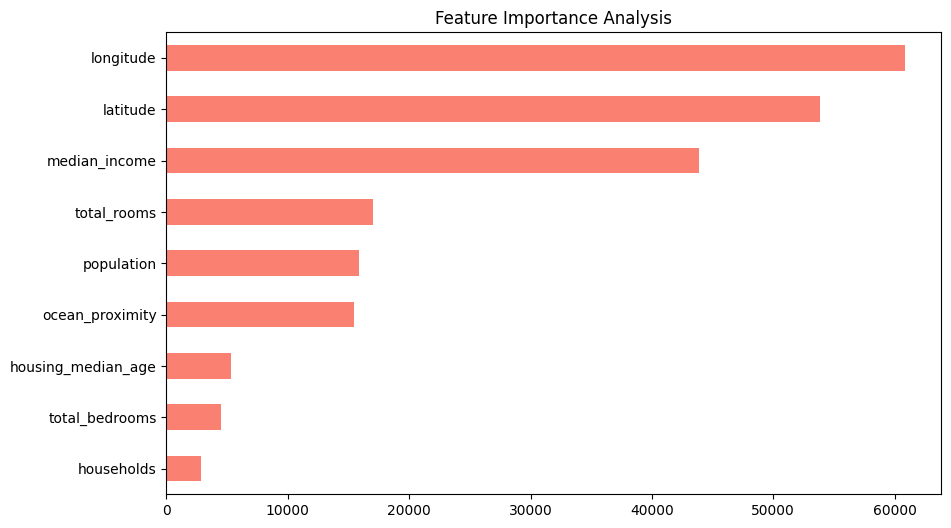

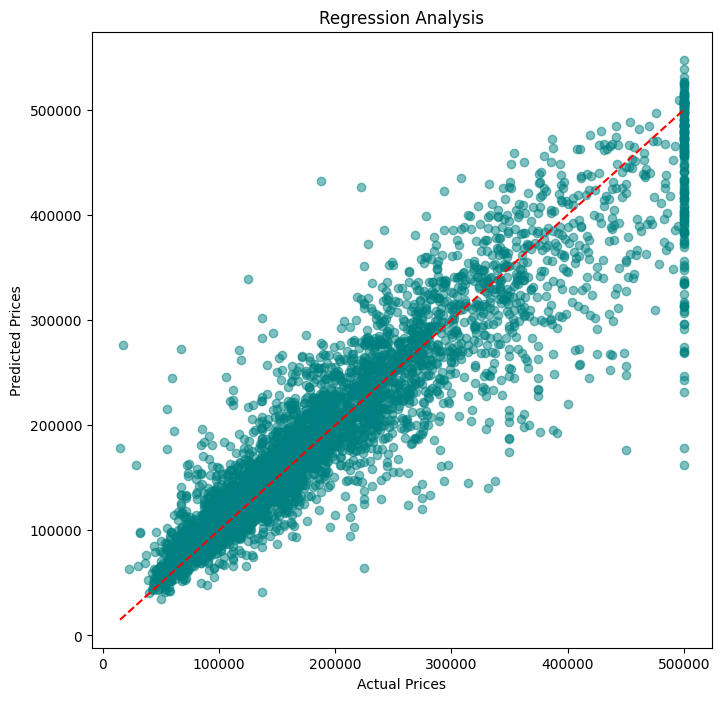

In [8]:
import matplotlib.pyplot as plt

importance = predictor.feature_importance(test_data)
importance['importance'].sort_values().plot(kind='barh', color='salmon', figsize=(10, 6))
plt.title('Feature Importance Analysis')
plt.show()


y_test = test_data['median_house_value']
y_pred = predictor.predict(test_data)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Regression Analysis')
plt.show()

In [7]:

predictions = predictor.predict(test_data.head())
print("Sample Predictions:\n", predictions)
predictor.save("housing_model_final")
print("\nModel saved successfully!")

Sample Predictions:
 20046     43575.796875
3024      98805.757812
15663    461358.375000
20484    258409.859375
9814     247209.671875
Name: median_house_value, dtype: float32

Model saved successfully!
